In [71]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import matplotlib.pyplot as plt
from design_friendly.models import models_filepath
from design_friendly.utils.easy import easy_grad, easy
from design_friendly.utils.get_flowmodel import get_flowmodel
from design_friendly.utils.iea22 import IEA22
from design_friendly.utils.plot_utils import lut_3d_heatmap
from design_friendly.utils.pred import torchscript_to_lut
from design_friendly.utils.sites import Hornsrev1Site
from design_friendly.utils.graph import graph_maker
from design_friendly.utils.vjp import (
    make_dP_dz_inflowgrid,
    prepare_from_graphs,
    jac_gamma,
    gradP_vjp_xy_inflowgrid_prepared,
)
from py_wake import numpy as np

# contains a single random layout from test set
# test_graphs = torch.load(models_filepath + "sample.pt", weights_only=False)
# ts_path = models_filepath + "best.ptnox.torchscript.pt"
ts_path = models_filepath + "torchscript26a.pt"
np.set_printoptions(suppress=True)

In [73]:
wt = IEA22()
wf_model = get_flowmodel(wt=wt)

# grph = test_graphs[0]
# X_fix = grph["pos"][:, 0]
# Y_fix = grph["pos"][:, 1]
X_fix, Y_fix, _ = Hornsrev1Site(
    scale_D=wt.diameter()  # scale up the layout based on turbine diameter ratio
)
X_fix = X_fix
Y_fix = Y_fix

# wind rose
wds = np.arange(0, 360, 15)
wss = np.arange(3, 10, 1)
TI = 0.04  # single TI for now
tilt = 0
print(len(wds) * len(wss))
n_threads = 2

lut_graphs = graph_maker(
    x=X_fix,
    y=Y_fix,
    wd=wds,
    ws=wss,
    TI=TI,  # single TI for now
    target_dicts=None,
    # per_turbines=False,
    connectivity="wake_aware",
    num_threads=n_threads,
    lut=True
)

INFO:design_friendly.utils.graph: generated 168 graphs from 168 cases


168


'generate_graphs // n=287 // 0.087 s // total=4325 s'

'graph_maker // n=287 // 0.089 s // total=4325 s'

In [74]:
# packed PyWake gradient function
dP_dz = make_dP_dz_inflowgrid(wf_model)
# mega-graphs for efficient batching from inflow/geometry
prepared = prepare_from_graphs(
    lut_graphs,
    lut=True,
    n_wd = len(wds),
    edge_uv_cols=(0, 1),
)

dP_dxy_list, gamma_list = gradP_vjp_xy_inflowgrid_prepared(
    ts_path=ts_path,
    prepared=prepared,
    dP_dz=dP_dz,
    gamma_col=-1,
    uv_scale=1.0,
    return_gamma=True,
)

'make_dP_dz_inflowgrid // n=7 // 0.000 s // total=1947 s'

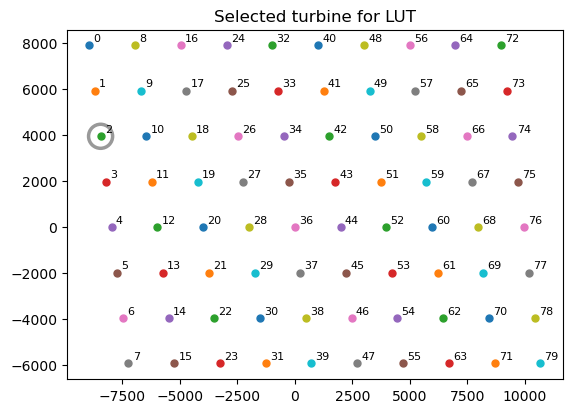

'torchscript_to_lut // n=14 // 0.000 s // total=4162 s'

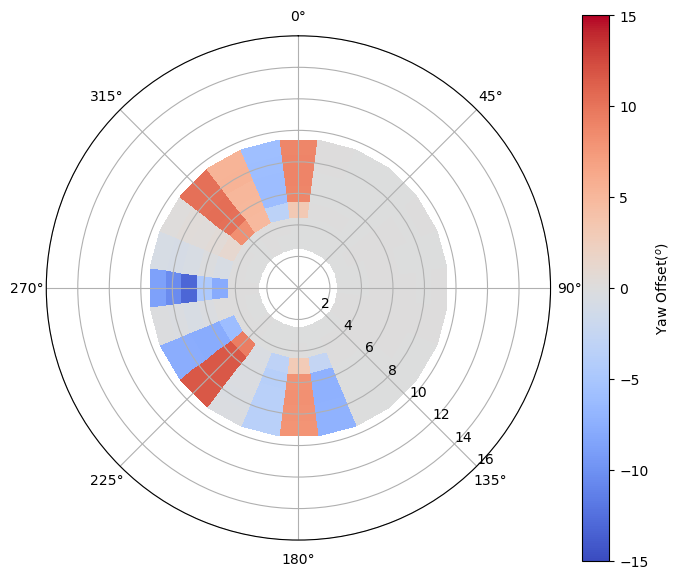

In [75]:
# plot look-up-table based on predictions
turbine_idx = int(2)  # select a turbine to plot

plt.figure()
for i, (xi, yi) in enumerate(zip(X_fix, Y_fix)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(
        str(i),
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )
plt.gca().set_aspect("equal", adjustable="box")
plt.scatter(
    X_fix[turbine_idx],
    Y_fix[turbine_idx],
    marker="o",
    facecolors="none",
    edgecolors="k",
    linewidths=2.5,
    s=300,
    alpha=0.4,
)
plt.title("Selected turbine for LUT")
plt.show()

# Plot LUT for turbine_idx

gamma_arr = torchscript_to_lut(gamma_list, wds, wss)

lut_3d_heatmap(gamma_arr[turbine_idx, :, :], wds=wds, wss=wss)

INFO:design_friendly.utils.graph: generated 168 graphs from 168 cases


'generate_graphs // n=288 // 0.079 s // total=4341 s'

'graph_maker // n=288 // 0.080 s // total=4341 s'

'predict_torchscript // n=26 // 1.974 s // total=4157 s'

'torchscript_to_lut // n=15 // 0.000 s // total=4165 s'

'easy // n=13 // 2.060 s // total=1596 s'

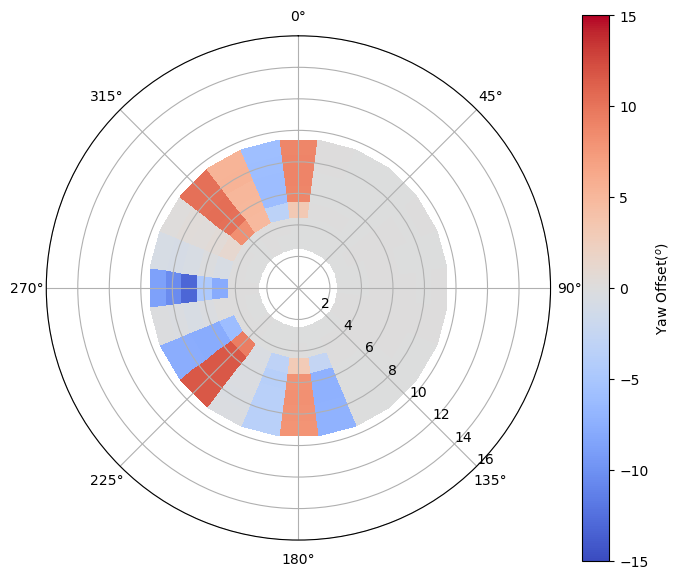

In [76]:
gamma_pred = easy(
    X_fix, Y_fix, wd=wds, ws=wss, TI=TI, num_threads=n_threads, lut=True
)

lut_3d_heatmap(gamma_pred[turbine_idx, :, :], wds=wds, wss=wss)

In [77]:
# case
# this is a smoother version of PyWake IEA22 that works better with wake steering optimization
wt = IEA22()
# wds = np.array([270])
# wss = np.array([6])
x, y, site = Hornsrev1Site(
    scale_D=wt.diameter()  # scale up the layout based on turbine diameter ratio
)
TI = 0.04  # site.local_wind().TI_ilk.ravel()s

# predict timeseries
n_t = 100  # set ts to genereate
wdt = np.random.uniform(0, 360, n_t)
wst = np.random.uniform(3, 25, n_t)
# TI = np.random.uniform(0.02, 0.14, n_t)
TI = np.array(0.04)

INFO:design_friendly.utils.graph: generated 160 graphs from 160 cases


'generate_graphs // n=289 // 0.162 s // total=4344 s'

'graph_maker // n=289 // 0.166 s // total=4344 s'

'predict_torchscript // n=27 // 2.188 s // total=4160 s'

'easy // n=14 // 2.358 s // total=1599 s'

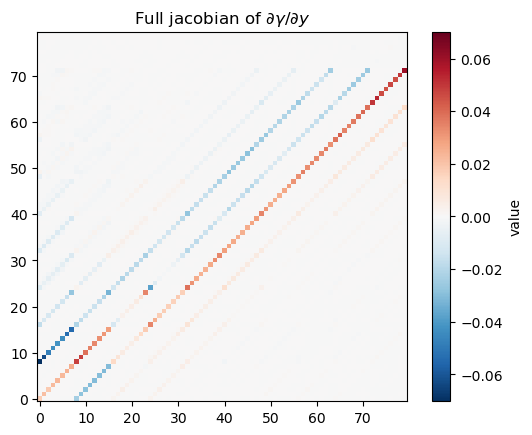

How does perturbing Y axis affect the optimal Yaw we get from GNN


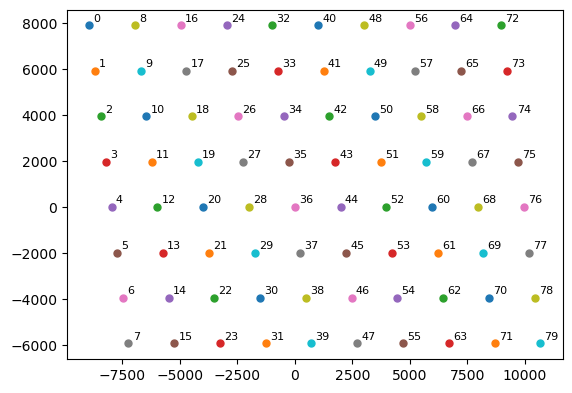

In [78]:
# d gamma /d Y (coord)
xo, yo, site = Hornsrev1Site(
    scale_D=wt.diameter()  # scale up the layout based on turbine diameter ratio
)
yo = np.asarray(yo)  # [:60]
xo = np.asarray(xo)  # [:60]
n = yo.size
h = 2

X = np.repeat(xo[None, :], 2 * n, axis=0)  # (2n, n_wt)
Y = np.repeat(yo[None, :], 2 * n, axis=0)  # (2n, n_wt)
i = np.arange(n)
Y[i, i] += h
Y[i + n, i] -= h

wdt = np.full((2 * n, 1), 271.0)  # (2n,) per-case
wst = np.full((2 * n, 1), 6.0)  # (2n,)
TI = np.full(2 * n, 0.06)  # (2n,)

yaw_pm = np.asarray(
    easy(X, Y, wd=wdt, ws=wst, TI=TI, num_threads=n_threads, lut=False)
)  # ()
d = (yaw_pm[:n] - yaw_pm[n:]) / (2 * h)  # leading axis is the perturbed index j
J = np.moveaxis(d, 0, -1).squeeze()  # yaw_shape + (n,)


m = abs(J).max()
fig, ax = plt.subplots()
im = ax.imshow(
    J,
    origin="lower",
    aspect="equal",
    vmin=-m,
    vmax=m,
    cmap="RdBu_r",
)
fig.colorbar(im, ax=ax, label="value")
plt.title("Full jacobian of $\partial \gamma / \partial y$")
plt.show()
print('How does perturbing Y axis affect the optimal Yaw we get from GNN')
# layout

plt.figure()
for i, (xi, yi) in enumerate(zip(xo, yo)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(
        str(i),
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

In [ ]:
# d gamma /d Y (coord)
# finite diff. jacobian
xo, yo, site = Hornsrev1Site(
    scale_D=wt.diameter()  # scale up the layout based on turbine diameter ratio
)

wd__ = np.array([91.0])
ws__ = np.array([7.0])
TI__ = np.array([0.06])

k = 3  # kxk hornsrev
stride = 8  # original hornsrev 8x8
idx = (np.arange(k)[:, None] * stride + np.arange(k)).ravel()

yo = np.asarray(yo)[idx]
xo = np.asarray(xo)[idx]
n = yo.size
h = 1

X = np.repeat(xo[None, :], 2 * n, axis=0)  # (2n, n_wt)
Y = np.repeat(yo[None, :], 2 * n, axis=0)  # (2n, n_wt)
i = np.arange(n)
Y[i, i] += h
Y[i + n, i] -= h

wdt = np.full((2 * n, 1), wd__)  # (2n,) per-case
wst = np.full((2 * n, 1), ws__)  # (2n,)
TI = np.full(2 * n, TI__)  # (2n,)

yaw_pm = np.asarray(easy(X, Y, wd=wdt, ws=wst, TI=TI, num_threads=n_threads, lut=False))
d = (yaw_pm[:n] - yaw_pm[n:]) / (2 * h)  # !!leading axis is the perturbed index j!!
J = np.moveaxis(d, 0, -1).squeeze()  # yaw_shape + (n,)

yaw_at = easy(xo, yo, wd=wd__, ws=ws__, TI=TI__, num_threads=n_threads, lut=False)


m = abs(J).max()
fig, ax = plt.subplots()
im = ax.imshow(
    J,
    origin="lower",
    aspect="equal",
    vmin=-m,
    vmax=m,
    cmap="RdBu_r",
)
fig.colorbar(im, ax=ax, label="$\partial \gamma / \partial y$")
labels = [f"WT{i}" for i in range(n)]
ax.set_xticks(range(J.shape[1]))
ax.set_yticks(range(J.shape[0]))
ax.set_xticklabels(labels[: J.shape[1]], rotation=90)
ax.set_yticklabels(labels[: J.shape[0]])
plt.title(
    "Full jacobian of $\partial \gamma / \partial y$ \n (Perturbing the Y coordinate of the turbines) \n(Perturbed turbines on x axis)"
)
plt.show()

# layout

plt.figure()
for i, (xi, yi) in enumerate(zip(xo, yo)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(
        f"WT{i} ({yaw_at[i].item():.1f}$^\circ$)",
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )
plt.gca().set_aspect("equal", adjustable="box")
plt.show()


# autograd jacobian

from utils.vjp import jac_gamma


lut_graphs = graph_maker(
    x=xo,
    y=yo,
    wd=wd__,
    ws=ws__,
    TI=TI__,  # single TI for now
    target_dicts=None,
    # per_turbines=False,
    connectivity="wake_aware",
    num_threads=n_threads,
    lut=False,
)

prepared = prepare_from_graphs(
    lut_graphs,
    edge_uv_cols=(0, 1),
    lut=False,
)

jjj, gamma_jac = jac_gamma(ts_path, prepared, return_gamma=True)

jjj_y = np.array(jjj)[:, :, :, 1].squeeze()
gamma_jac = np.array(gamma_jac).squeeze()


m = abs(jjj_y).max()
fig, ax = plt.subplots()
im = ax.imshow(
    jjj_y,
    origin="lower",
    aspect="equal",
    vmin=-m,
    vmax=m,
    cmap="RdBu_r",
)
fig.colorbar(im, ax=ax, label="$\partial \gamma / \partial y$")
labels = [f"WT{i}" for i in range(n)]
ax.set_xticks(range(jjj_y.shape[1]))
ax.set_yticks(range(jjj_y.shape[0]))
ax.set_xticklabels(labels[: jjj_y.shape[1]], rotation=90)
ax.set_yticklabels(labels[: jjj_y.shape[0]])
plt.title(
    "Full jacobian of $\partial \gamma / \partial y$ \n (Perturbing the Y coordinate of the turbines) \n(Perturbed turbines on x axis)"
)
plt.show()

# layout

plt.figure()
for i, (xi, yi) in enumerate(zip(xo, yo)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(
        f"WT{i} ({gamma_jac[i].item():.1f}$^\circ$)",
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

'easy // n=19 // 0.000 s // total=1726 s'

TypeError: easy() got an unexpected keyword argument 'ts_path'

In [80]:
# TODO: Compare dP/dy using GNN partials  and \delta P/ \delta y @ \gamma^* from PyWake partials

from py_wake.utils.gradients import autograd, fd


def power_pywake(x, y, yaw):
    _, _, power_ilk, _, _, _ = wf_model(
        x,
        y,
        wd=wd__,  # (n_wd_eff,)
        ws=ws__,  # (n_ws,)
        TI=TI__,
        yaw=yaw,  # (n_wt, n_wd_eff, 1)
        tilt=0,
        return_simulationResult=False,
    )
    return power_ilk.sum()


py_grads_dpowerdyaw = autograd(
    lambda yaw: power_pywake(yaw=yaw, x=xo, y=yo), argnum=0, vector_interdependence=True
)

lut_graphs = graph_maker(
    x=xo,
    y=yo,
    wd=wd__,
    ws=ws__,
    TI=TI__,  # single TI for now
    target_dicts=None,
    # per_turbines=False,
    connectivity="wake_aware",
    num_threads=n_threads,
    lut=False,
)

prepared = prepare_from_graphs(
    lut_graphs,
    edge_uv_cols=(0, 1),
    lut=False,
)


J_list, gamma_list = jac_gamma(ts_path, prepared, return_gamma=True)

print("PyWake gradients, power wrt. yaw")
py_grads_dpowerdyaw(gamma_list[0])  # watts/deg  # dpower/dgamma

INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases


'generate_graphs // n=293 // 0.004 s // total=4349 s'

'graph_maker // n=293 // 0.006 s // total=4349 s'

PyWake gradients, power wrt. yaw


array([  186.47151526,   186.470717  ,   186.47101419,  5437.50557523,
        5437.51101127,  5437.51956282, 21747.7606902 , 21747.74786555,
       21747.72301216])

# full chain-rule gradients dP/ds
(VJP)

# $dP/ds = \partial P / \partial s |_{\gamma*}^{PyWake} + \partial P / \partial \gamma |_{s*}^{PyWake} \cdot   \partial \gamma / \partial s |_{\gamma*, s*}^{GNN} \,,\qquad \gamma*=GNN(...)$

In [81]:
from design_friendly.utils.easy import easy_grad

wd__, ws__, TI__ = 92., 7., 0.06
yo = [0, 0, 0]
xo = np.array([0, 4, 8])*wt.diameter()
easy_dP = easy_grad(wf_model=wf_model, coords=(xo, yo))  # , time=True
dP_dxy = np.asarray(easy_dP(wd=wd__, ws=ws__, TI=TI__))
dP_dxy.squeeze()  # .reshape(n, 2)  # compare this to pywake gradients at GNN_gamma

'make_dP_dz_inflowgrid // n=8 // 0.000 s // total=1972 s'

'easy_grad // n=4 // 0.002 s // total=1739 s'

INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases


'generate_graphs // n=294 // 0.002 s // total=4350 s'

'graph_maker // n=294 // 0.004 s // total=4350 s'

array([[ -2093.0908 , -15905.243  ],
       [   -52.49878,  -2026.2662 ],
       [  2145.5898 ,  17931.508  ]], dtype=float32)

# Autograd dP/ds at GNN setpoints $\partial P / \partial s |_{\gamma*}^{PyWake}$

In [82]:
# Evaluate dPower wrt. yaw at GNN predicted yaw
gamma_ = easy(xo, yo, wd=wd__, ws=ws__, TI=TI__, num_threads=n_threads).squeeze()


py_grads_dpowerdxy = autograd(
    lambda x, y: power_pywake(x=x, y=y, yaw=gamma_),
    argnum=[0, 1],
    vector_interdependence=True,
)
# \del P / \del \s |_{\gamma*}
np.array(py_grads_dpowerdxy(xo, yo)).T

INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases


'generate_graphs // n=295 // 0.004 s // total=4350 s'

'graph_maker // n=295 // 0.006 s // total=4350 s'

'predict_torchscript // n=30 // 0.019 s // total=4164 s'

'torchscript_to_lut // n=16 // 0.000 s // total=4172 s'

'easy // n=17 // 0.029 s // total=1603 s'

array([[ -2066.73190124, -14071.66803936],
       [   278.13076718,  -1976.60630094],
       [  1788.60113405,  16048.2743403 ]])

# Autograd dP/ds at GNN setpoints $\partial P / \partial s |_{\gamma=0}^{PyWake}$

In [83]:
# Evaluare dPower wrt. yaw at yaw = 0
py_grads_dpowerdxy_at0yaw = autograd(
    lambda x, y: power_pywake(x=x, y=y, yaw=0),
    argnum=[0, 1],
    vector_interdependence=True,
)

# \del P / \del s |_{\gamma=0}
np.array(py_grads_dpowerdxy_at0yaw(xo, yo)).T

array([[-1711.5074765 , -6893.95997394],
       [  287.56158721, -2891.01499293],
       [ 1423.94588929,  9784.97496687]])

INFO:design_friendly.utils.graph: generated 162 graphs from 162 cases


'generate_graphs // n=296 // 0.099 s // total=4351 s'

'graph_maker // n=296 // 0.103 s // total=4351 s'

'predict_torchscript // n=31 // 0.090 s // total=4165 s'

'easy // n=18 // 0.196 s // total=1604 s'

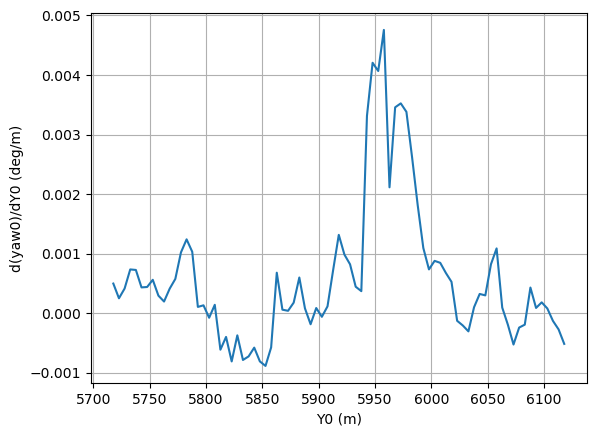

In [84]:
def sweep_single_turbine_y_jacobian(
    xo,
    yo,
    *,
    i0=1,
    y0_sweep,
    h=1.0,
    wd__=np.array([90.0]),
    ws__=np.array([7.0]),
    TI__=np.array([0.06]),
):
    y0_sweep = np.asarray(y0_sweep)
    m = y0_sweep.size
    n = yo.size

    # Build 2m cases: first m are +h, next m are -h around each sweep point.
    X = np.repeat(xo[None, :], 2 * m, axis=0)  # (2m, n_wt)
    Y = np.repeat(yo[None, :], 2 * m, axis=0)  # (2m, n_wt)

    Y[:m, i0] = y0_sweep + h
    Y[m:, i0] = y0_sweep - h

    wdt = np.full((2 * m, 1), wd__)  # (2m, 1)
    wst = np.full((2 * m, 1), ws__)  # (2m, 1)
    TI = np.full(2 * m, TI__)  # (2m,)

    yaw_pm = np.asarray(
        easy(
            X,
            Y,
            wd=wdt,
            ws=wst,
            TI=TI,
            num_threads=n_threads,
            lut=False,
        )
    )
    dyaw_dy0 = (yaw_pm[:m] - yaw_pm[m:]) / (2 * h)
    return y0_sweep, dyaw_dy0


xo, yo, site = Hornsrev1Site(
    scale_D=wt.diameter()  # scale up the layout based on turbine diameter ratio
)

wd__ = np.array([91.0])
ws__ = np.array([7.0])
TI__ = np.array([0.06])

k = 3  # kxk hornsrev
stride = 8  # original hornsrev 8x8
idx = (np.arange(k)[:, None] * stride + np.arange(k)).ravel()

yo = np.asarray(yo)[idx]
xo = np.asarray(xo)[idx]
n = yo.size
h = 1




# choose a sweep range (absolute Y values)
y0_sweep = yo[1] + np.linspace(-200.0, 200.0, 81)

y0_sweep, dyaw_dy0 = sweep_single_turbine_y_jacobian(
    xo,
    yo,
    i0=1,
    y0_sweep=y0_sweep,
    h=1.0,
    wd__=wd__,
    ws__=ws__,
    TI__=TI__,
)


plt.plot(y0_sweep, dyaw_dy0[:, 1])
plt.xlabel("Y0 (m)")
plt.ylabel("d(yaw0)/dY0 (deg/m)")
plt.grid(True)
plt.show()

INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases


'generate_graphs // n=377 // 0.002 s // total=4361 s'

'graph_maker // n=377 // 0.004 s // total=4361 s'

INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:design_friendly.utils.graph: generated 1 graphs from 1 cases
INFO:desig

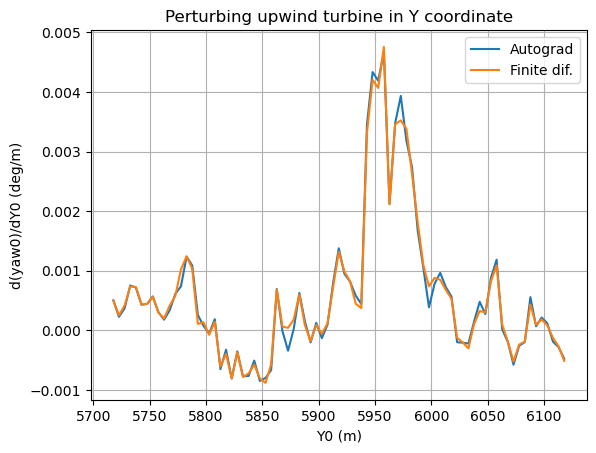

In [85]:
def sweep_gamma_jacobian_y0(
    ts_path,
    xo,
    yo,
    *,
    i0=1,
    y0_sweep=None,
    wds=None,
    wss=None,
    TI=None,
):
    y0_sweep = np.asarray(y0_sweep)
    I = yo.size
    m = y0_sweep.size
    dgamma_dy0 = np.empty((m, I), dtype=np.float32)  # (m, I)
    gamma0 = np.empty((m, I), dtype=np.float32)  # (m, I)
    for t, y0 in enumerate(y0_sweep):
        y_new = yo.copy()
        y_new[i0] = y0
        lut_graphs = graph_maker(
            x=xo,
            y=y_new,
            wd=wds,
            ws=wss,
            TI=TI,  # single TI for now
            target_dicts=None,
            # per_turbines=False,
            connectivity="wake_aware",
            num_threads=n_threads,
            lut=False,
        )
        prepared = prepare_from_graphs(
            lut_graphs,
            edge_uv_cols=(0, 1),
            lut=False,
        )

        J_list, gamma_list = jac_gamma(ts_path, prepared, return_gamma=True)
        Jm_xy = J_list[0]  # (I, I, 2)
        gm = gamma_list[0]  # (I,)
        dgamma_dy0[t, :] = Jm_xy[:, i0, 1]
        gamma0[t, :] = gm
    return y0_sweep, dgamma_dy0, gamma0


y0_sweep = yo[1] + np.linspace(-200.0, 200.0, 81)
y0_sweep, dgamma_dy0_auto, gamma0 = sweep_gamma_jacobian_y0(
    ts_path,
    xo,
    yo,
    i0=1,
    y0_sweep=y0_sweep,
    wds=wd__,
    wss=ws__,
    TI=TI__,
)

plt.plot(y0_sweep, dgamma_dy0_auto[:, 1], label="Autograd")
plt.plot(y0_sweep, dyaw_dy0[:, 1], label="Finite dif.")
plt.title("Perturbing upwind turbine in Y coordinate")
plt.xlabel("Y0 (m)")
plt.ylabel("d(yaw0)/dY0 (deg/m)")
plt.grid(True)
plt.legend()
plt.show()

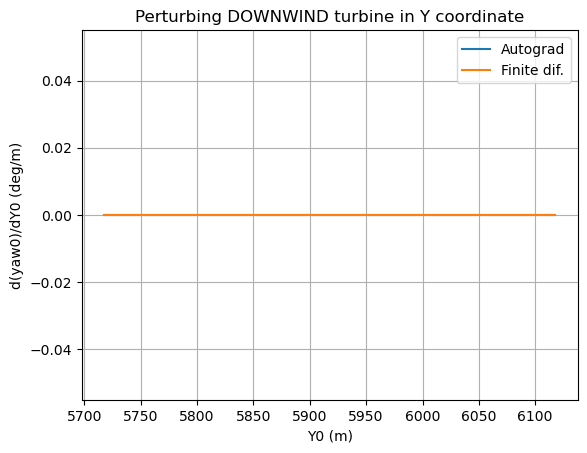

In [86]:
d_yaw0_dy0down = dyaw_dy0[:, 0]  # (m,)
dgamma0_dy0_autodown = dgamma_dy0_auto[:, 0]  # (m,)

plt.plot(y0_sweep, dgamma0_dy0_autodown, label="Autograd")
plt.plot(y0_sweep, d_yaw0_dy0down, label="Finite dif.")
plt.title("Perturbing DOWNWIND turbine in Y coordinate")
plt.xlabel("Y0 (m)")
plt.ylabel("d(yaw0)/dY0 (deg/m)")
plt.grid(True)
plt.legend()
plt.show()